# Notebook 13 — Violation Root Cause Analysis

17.1% of cases have a travel-ordering violation (Type A: departed before permit submitted; Type B: departed before approval). This notebook identifies *which* case characteristics predict violations.

**Approach:**
- **Target**: `has_violation` — fitness < 1.0 from token replay (Notebook 05)
- **Features**: department, budget quartile, seasonality, case complexity (n_events, rejections, reminders) — all retrospective, no leakage concern since we're explaining past violations, not predicting future ones
- **Techniques**: Decision tree (interpretable rules) + XGBoost (ranking importance) + SHAP

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay)
import xgboost as xgb
import shap

ROOT = Path.cwd().parent
T    = ROOT / 'outputs' / 'tables'
OUT  = ROOT / 'outputs' / 'figures'
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
from src.load_event_log import load_xes_log

log = load_xes_log(ROOT / 'data' / 'raw' / 'PermitLog.xes', legacy=True)
rows = []
for trace in log:
    cid    = trace.attributes.get('concept:name', '')
    dept   = trace.attributes.get('case:OrganizationalEntity', '')
    budget = trace.attributes.get('case:RequestedBudget', np.nan)
    for evt in trace:
        rows.append({
            'case_id':   cid,
            'activity':  str(evt['concept:name']),
            'timestamp': evt['time:timestamp'],
            'dept':      dept,
            'budget':    budget,
        })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

# Load conformance results from Notebook 05
conf = pd.read_csv(T / 'conformance_replay.csv')
print(f'Conformance table: {conf.shape}  columns: {conf.columns.tolist()}')
print(conf.head(3))

parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 8772.41it/s] 


Conformance table: (7065, 7)  columns: ['case_id', 'fitness', 'missing_tokens', 'remaining_tokens', 'consumed_tokens', 'produced_tokens', 'is_fit']
               case_id   fitness  missing_tokens  remaining_tokens  \
0  travel permit 76455  0.894737               2                 2   
1  travel permit 76665  0.894737               2                 2   
2  travel permit 73652  0.894737               2                 2   

   consumed_tokens  produced_tokens  is_fit  
0               19               19   False  
1               19               19   False  
2               19               19   False  


In [3]:
# Build case-level feature table
case_grp   = df.groupby('case_id')
case_start = case_grp['timestamp'].min()
case_end   = case_grp['timestamp'].max()

# Violation type flags from saved tables
vio_a = pd.read_csv(T / 'violation_type_a.csv')
vio_b = pd.read_csv(T / 'violation_type_b.csv')
vio_a_ids = set(vio_a['case_id']) if 'case_id' in vio_a.columns else set(vio_a.iloc[:, 0])
vio_b_ids = set(vio_b['case_id']) if 'case_id' in vio_b.columns else set(vio_b.iloc[:, 0])

feat_rows = []
for cid, grp in case_grp:
    t0       = case_start[cid]
    t_end    = case_end[cid]
    duration = (t_end - t0).total_seconds() / 86400
    dept     = grp['dept'].iloc[0]
    budget   = grp['budget'].iloc[0]
    n_evts   = len(grp)
    n_rej    = grp['activity'].str.contains('REJECTED').sum()
    n_rem    = (grp['activity'] == 'Send Reminder').sum()
    n_app    = grp['activity'].str.contains('APPROVED').sum()
    has_final = int('Permit FINAL_APPROVED by SUPERVISOR' in grp['activity'].values)

    start_month   = t0.month
    start_quarter = (start_month - 1) // 3 + 1
    start_dow     = t0.dayofweek

    fitness_row = conf[conf.iloc[:, 0] == cid]
    fitness     = fitness_row['fitness'].values[0] if len(fitness_row) else 1.0
    has_vio     = int(fitness < 1.0)
    type_a      = int(cid in vio_a_ids)
    type_b      = int(cid in vio_b_ids)

    feat_rows.append({
        'case_id':            cid,
        'dept':               dept,
        'budget':             budget,
        'n_events':           n_evts,
        'n_rejections':       n_rej,
        'n_reminders':        n_rem,
        'n_approvals':        n_app,
        'has_final_approved': has_final,
        'duration_days':      duration,
        'start_month':        start_month,
        'start_quarter':      start_quarter,
        'start_dow':          start_dow,
        'has_violation':      has_vio,
        'type_a':             type_a,
        'type_b':             type_b,
    })

feat_df = pd.DataFrame(feat_rows)

# Encode department
dept_enc = LabelEncoder()
feat_df['dept_enc'] = dept_enc.fit_transform(feat_df['dept'].fillna('Unknown'))

# Budget quartile — safe: fall back to fewer bins if duplicates collapse edges
def safe_budget_quartile(s, q=4):
    s_valid = s.dropna()
    n_unique = s_valid.nunique()
    actual_q = min(q, n_unique)
    labels   = list(range(1, actual_q + 1))
    result   = pd.qcut(s, q=actual_q, labels=labels, duplicates='drop')
    return result.astype(float)

feat_df['budget_q'] = safe_budget_quartile(feat_df['budget'])

n_vio = feat_df['has_violation'].sum()
print(f'Cases: {len(feat_df):,}  |  Violations: {n_vio:,} ({n_vio/len(feat_df):.1%})')
print(f'Type A: {feat_df["type_a"].sum():,}  |  Type B: {feat_df["type_b"].sum():,}')
print(f'Both A+B: {(feat_df["type_a"] & feat_df["type_b"]).sum():,}')
print(f'Budget quartiles: {feat_df["budget_q"].value_counts().sort_index().to_dict()}')

Cases: 7,065  |  Violations: 3,174 (44.9%)
Type A: 746  |  Type B: 583
Both A+B: 0
Budget quartiles: {}


## 1. Violation rate by department and budget

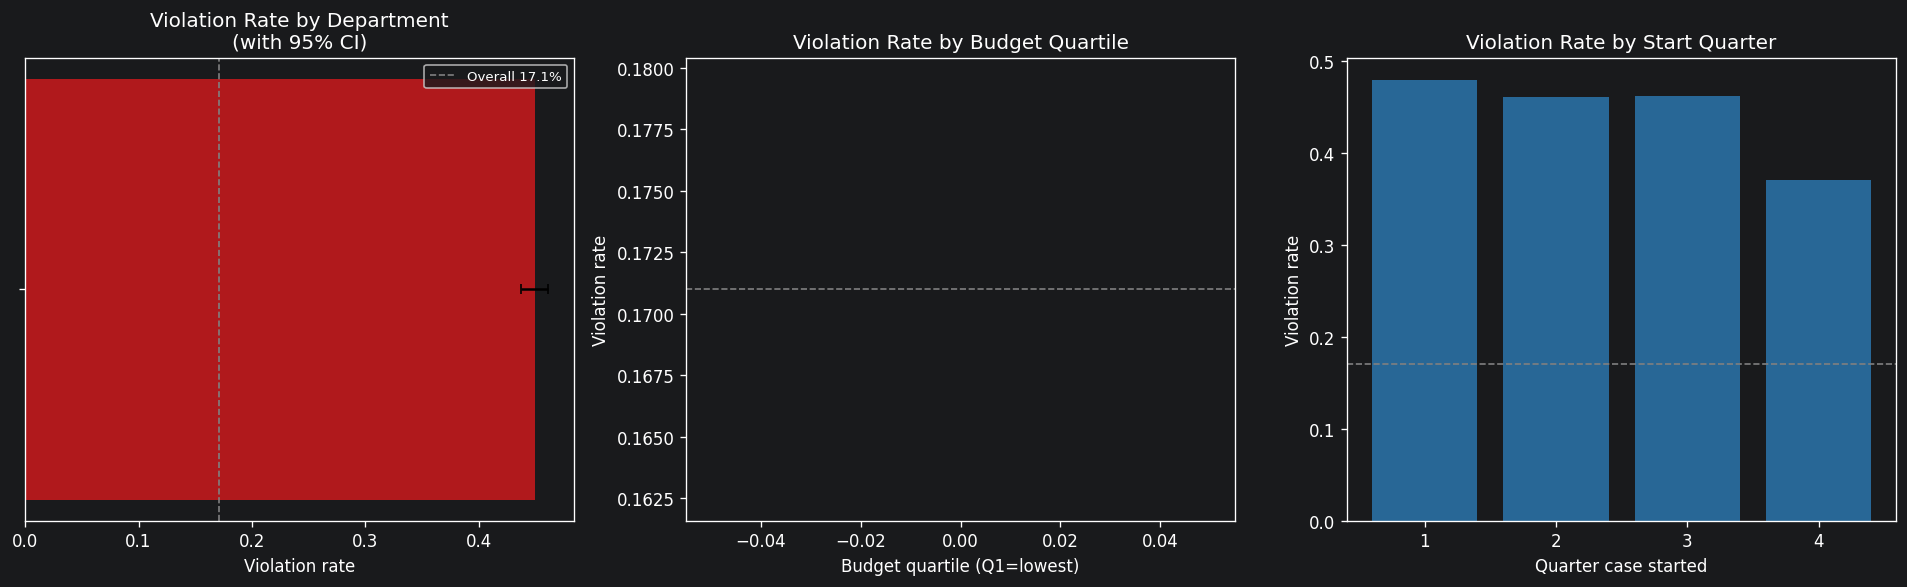

Saved violation_rca_distributions.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Violation rate by department ──────────────────────────────────────────
dept_vio = (feat_df.groupby('dept')
            .agg(n=('has_violation', 'count'),
                 vio=('has_violation', 'sum'))
            .assign(rate=lambda d: d['vio'] / d['n'])
            .sort_values('rate', ascending=True))

# Wilson 95% CI
z = 1.96
dept_vio['ci'] = z * np.sqrt(dept_vio['rate'] * (1 - dept_vio['rate']) / dept_vio['n'])

colors = ['#d7191c' if r > 0.171 else '#2c7bb6' for r in dept_vio['rate']]
axes[0].barh(range(len(dept_vio)), dept_vio['rate'], xerr=dept_vio['ci'],
             color=colors, alpha=0.8, capsize=3)
axes[0].axvline(0.171, color='grey', linestyle='--', linewidth=1, label='Overall 17.1%')
axes[0].set_yticks(range(len(dept_vio)))
axes[0].set_yticklabels([str(d)[:22] for d in dept_vio.index], fontsize=8)
axes[0].set_xlabel('Violation rate')
axes[0].set_title('Violation Rate by Department\n(with 95% CI)')
axes[0].legend(fontsize=8)

# ── Violation rate by budget quartile ────────────────────────────────────
bq_vio = (feat_df.dropna(subset=['budget_q'])
          .groupby('budget_q')
          .agg(n=('has_violation', 'count'), vio=('has_violation', 'sum'))
          .assign(rate=lambda d: d['vio'] / d['n']))
axes[1].bar(bq_vio.index.astype(str), bq_vio['rate'],
            color=['#2c7bb6','#abd9e9','#fdae61','#d7191c'], alpha=0.85)
axes[1].axhline(0.171, color='grey', linestyle='--', linewidth=1)
axes[1].set_xlabel('Budget quartile (Q1=lowest)')
axes[1].set_ylabel('Violation rate')
axes[1].set_title('Violation Rate by Budget Quartile')

# ── Violation rate by start quarter ──────────────────────────────────────
sq_vio = (feat_df.groupby('start_quarter')
          .agg(n=('has_violation', 'count'), vio=('has_violation', 'sum'))
          .assign(rate=lambda d: d['vio'] / d['n']))
axes[2].bar(sq_vio.index.astype(str), sq_vio['rate'],
            color='#2c7bb6', alpha=0.8)
axes[2].axhline(0.171, color='grey', linestyle='--', linewidth=1)
axes[2].set_xlabel('Quarter case started')
axes[2].set_ylabel('Violation rate')
axes[2].set_title('Violation Rate by Start Quarter')

plt.tight_layout()
fig.savefig(OUT / 'violation_rca_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

dept_vio[['n','vio','rate','ci']].to_csv(T / 'violation_rca_by_department.csv')
print('Saved violation_rca_distributions.png')

## 2. Decision tree — interpretable rules

In [5]:
FEAT_COLS = ['dept_enc', 'budget', 'n_events', 'n_rejections',
             'n_reminders', 'n_approvals', 'has_final_approved',
             'duration_days', 'start_month', 'start_quarter', 'start_dow']
FEAT_NAMES = ['Department', 'Budget', 'N events', 'N rejections',
              'N reminders', 'N approvals', 'Has final approval',
              'Duration (days)', 'Start month', 'Start quarter', 'Start day-of-week']

all_cols = list(dict.fromkeys(FEAT_COLS + ['has_violation']))
model_df = feat_df[all_cols].copy()
y        = model_df['has_violation'].values

# keep_empty_features=True prevents budget (mostly NaN) from being silently dropped
imp = SimpleImputer(strategy='median', keep_empty_features=True)
X   = imp.fit_transform(model_df[FEAT_COLS])
assert X.shape[1] == len(FEAT_NAMES), f'Shape mismatch: X has {X.shape[1]} cols, FEAT_NAMES has {len(FEAT_NAMES)}'

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30,
                             class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X, y)

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dt_auc = cross_val_score(dt, X, y, cv=cv, scoring='roc_auc').mean()
dt_acc = cross_val_score(dt, X, y, cv=cv, scoring='accuracy').mean()

print(f'Decision tree (depth=4) — CV AUC: {dt_auc:.3f}  |  CV accuracy: {dt_acc:.3f}')
print(f'Training set: {len(y):,} cases  |  Feature matrix: {X.shape}')
print()
print(export_text(dt, feature_names=FEAT_NAMES, max_depth=4))

Decision tree (depth=4) — CV AUC: 0.876  |  CV accuracy: 0.844
Training set: 7,065 cases  |  Feature matrix: (7065, 11)

|--- N events <= 13.50
|   |--- Has final approval <= 0.50
|   |   |--- N approvals <= 4.50
|   |   |   |--- Start month <= 11.50
|   |   |   |   |--- class: 1
|   |   |   |--- Start month >  11.50
|   |   |   |   |--- class: 1
|   |   |--- N approvals >  4.50
|   |   |   |--- N events <= 11.50
|   |   |   |   |--- class: 0
|   |   |   |--- N events >  11.50
|   |   |   |   |--- class: 1
|   |--- Has final approval >  0.50
|   |   |--- N approvals <= 3.50
|   |   |   |--- N events <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- N events >  7.50
|   |   |   |   |--- class: 1
|   |   |--- N approvals >  3.50
|   |   |   |--- N approvals <= 5.50
|   |   |   |   |--- class: 0
|   |   |   |--- N approvals >  5.50
|   |   |   |   |--- class: 0
|--- N events >  13.50
|   |--- N approvals <= 6.50
|   |   |--- N rejections <= 1.50
|   |   |   |--- N reminders <= 0.50
|

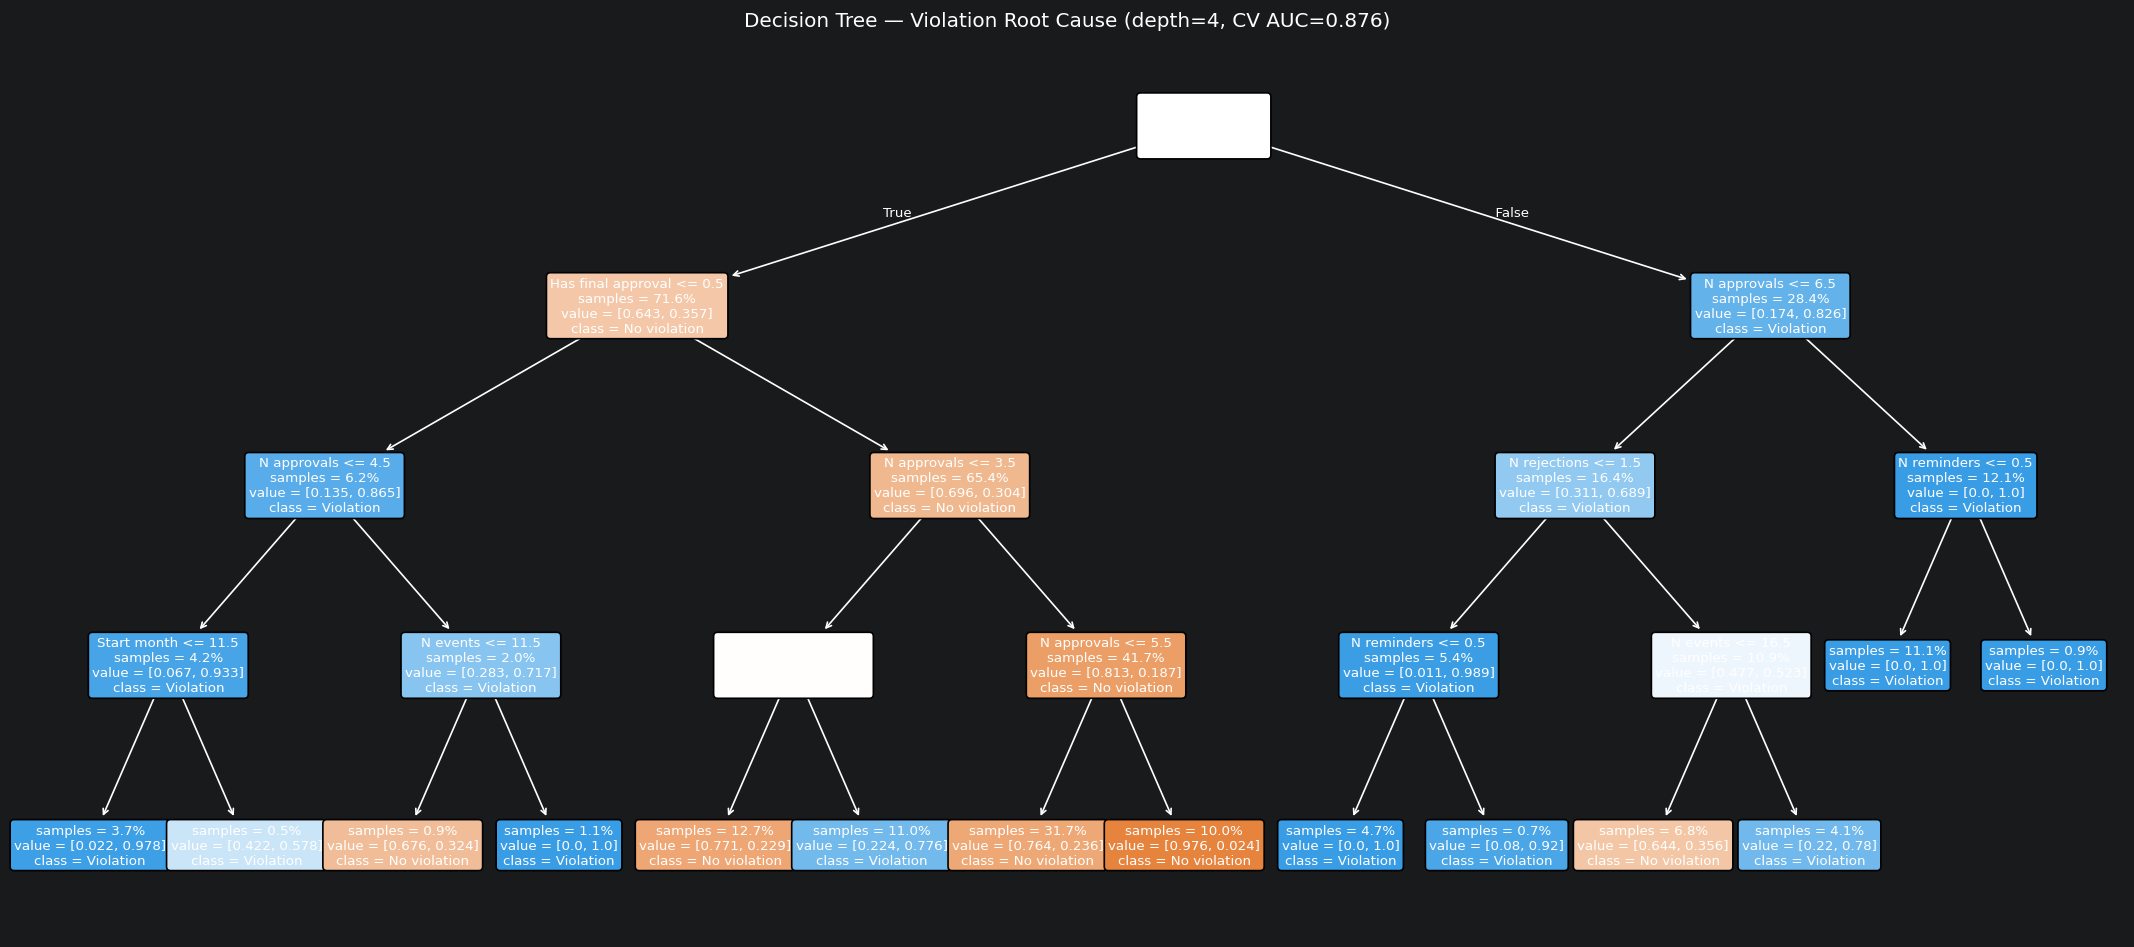

Saved violation_rca_decision_tree.png


In [6]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt, feature_names=FEAT_NAMES, class_names=['No violation', 'Violation'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True)
ax.set_title(f'Decision Tree — Violation Root Cause (depth=4, CV AUC={dt_auc:.3f})', fontsize=12)
plt.tight_layout()
fig.savefig(OUT / 'violation_rca_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved violation_rca_decision_tree.png')

## 3. XGBoost — feature importance + SHAP

XGBoost CV AUC: 0.956  (decision tree: 0.876)


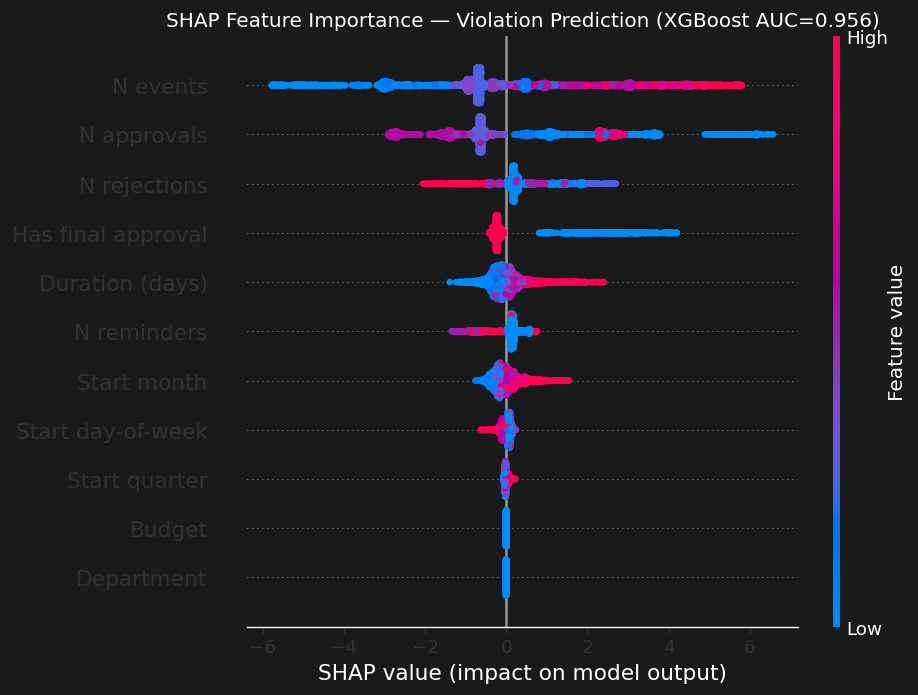

Saved violation_rca_shap.png


In [7]:
X_df = pd.DataFrame(X, columns=FEAT_NAMES)

xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                random_state=RANDOM_STATE, n_jobs=-1,
                                eval_metric='logloss')
xgb_model.fit(X_df, y)

xgb_auc = cross_val_score(xgb_model, X_df, y, cv=cv, scoring='roc_auc').mean()
print(f'XGBoost CV AUC: {xgb_auc:.3f}  (decision tree: {dt_auc:.3f})')

# SHAP
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer(X_df)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.beeswarm(shap_vals, max_display=11, show=False)
ax.set_title(f'SHAP Feature Importance — Violation Prediction (XGBoost AUC={xgb_auc:.3f})')
plt.tight_layout()
fig.savefig(OUT / 'violation_rca_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved violation_rca_shap.png')

## 4. High-risk segments — actionable summary

Segments by predicted risk band:
              n  violations  violation_rate  avg_duration  avg_budget  pct_of_all
risk_band                                                                        
Very low   1607         189        0.117610     99.800307         NaN    0.227459
Low        2240         451        0.201339     63.758709         NaN    0.317056
Medium      547         168        0.307130     81.986892         NaN    0.077424
High       1409        1104        0.783534     96.698894         NaN    0.199434
Very high  1262        1262        1.000000    105.481400         NaN    0.178627


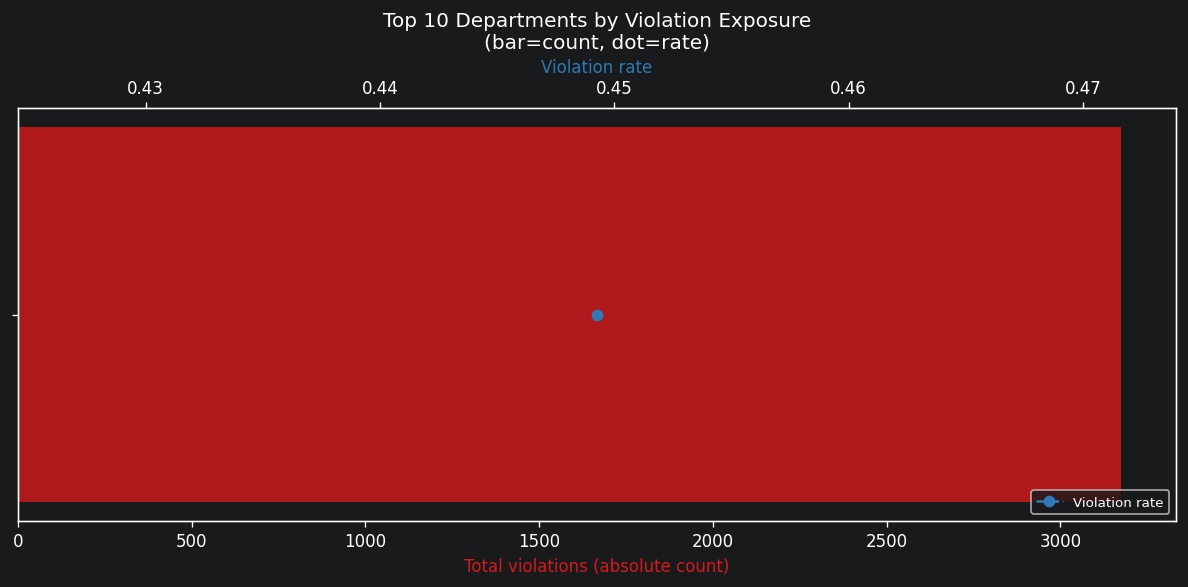

Saved violation_rca_dept_exposure.png


In [8]:
# Risk-segment summary using predicted probability quintiles
model_df2 = model_df.copy()
model_df2['pred_prob'] = dt.predict_proba(X)[:, 1]
model_df2['risk_band'] = pd.qcut(model_df2['pred_prob'], q=5,
                                  labels=['Very low','Low','Medium','High','Very high'],
                                  duplicates='drop')

segment_stats = (model_df2.groupby('risk_band', observed=True)
                 .agg(n=('has_violation','count'),
                      violations=('has_violation','sum'),
                      violation_rate=('has_violation','mean'),
                      avg_duration=('duration_days','mean'),
                      avg_budget=('budget','mean'))
                 .assign(pct_of_all=lambda d: d['n'] / len(model_df2)))

print('Segments by predicted risk band:')
print(segment_stats.to_string())
segment_stats.to_csv(T / 'violation_rca_segments.csv')

# Department risk exposure chart
dept_risk = dept_vio[['n','vio','rate']].copy()
dept_risk['risk_exposure'] = dept_risk['vio']
dept_risk = dept_risk.sort_values('risk_exposure', ascending=False)
dept_risk.to_csv(T / 'violation_rca_dept_risk.csv')

fig, ax = plt.subplots(figsize=(10, 5))
top_dept = dept_risk.head(10).sort_values('risk_exposure')
ax.barh(range(len(top_dept)), top_dept['risk_exposure'], color='#d7191c', alpha=0.8)
ax2 = ax.twiny()
ax2.plot(top_dept['rate'], range(len(top_dept)), 'o--', color='#2c7bb6',
         markersize=6, linewidth=1.5, label='Violation rate')
ax.set_yticks(range(len(top_dept)))
ax.set_yticklabels([str(d)[:25] for d in top_dept.index], fontsize=8)
ax.set_xlabel('Total violations (absolute count)', color='#d7191c')
ax2.set_xlabel('Violation rate', color='#2c7bb6')
ax.set_title('Top 10 Departments by Violation Exposure\n(bar=count, dot=rate)')
ax2.legend(loc='lower right', fontsize=8)
plt.tight_layout()
fig.savefig(OUT / 'violation_rca_dept_exposure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved violation_rca_dept_exposure.png')

## 5. Deep dive — the rejection paradox

The SHAP beeswarm shows **N rejections** pushing violation risk *left* (negative SHAP): more rejections → lower violation probability. This is counterintuitive — you might expect more rejections to correlate with more problems.

**Hypotheses to test:**
1. **Correction effect**: rejected cases are scrutinised, corrected, and re-submitted properly — the rejection acts as a quality gate.
2. **Bypass effect**: zero-rejection violators never engaged with the approval process at all — they departed first, submitted the claim after. There's nothing to reject because the proper sequence was never attempted.

If H2 is correct, we'd expect zero-rejection violators to have:
- Fewer total events (shorter traces — they skipped steps)
- Higher share of Type A violations (departed before permit submitted)
- Missing key activities like `Declaration APPROVED by BUDGET OWNER`

Violation rate by rejection count:
                 n  pct_cases  violations  vio_rate  type_a_rate  type_b_rate  median_events  median_duration
rej_bucket                                                                                                   
0 rejections  5153   0.729370        1972  0.382690     0.099554     0.080536           10.0        70.230185
1 rejection    157   0.022222         154  0.980892     0.089172     0.050955           11.0        87.442894
2 rejections  1320   0.186837         739  0.559848     0.125000     0.093182           14.0        70.233617
3+             435   0.061571         309  0.710345     0.124138     0.085057           20.0        87.323854

Zero-rejection violators  — median events: 10  mean: 12.6  n=1,972
Zero-rejection compliant  — median events: 10  mean: 9.6  n=3,181


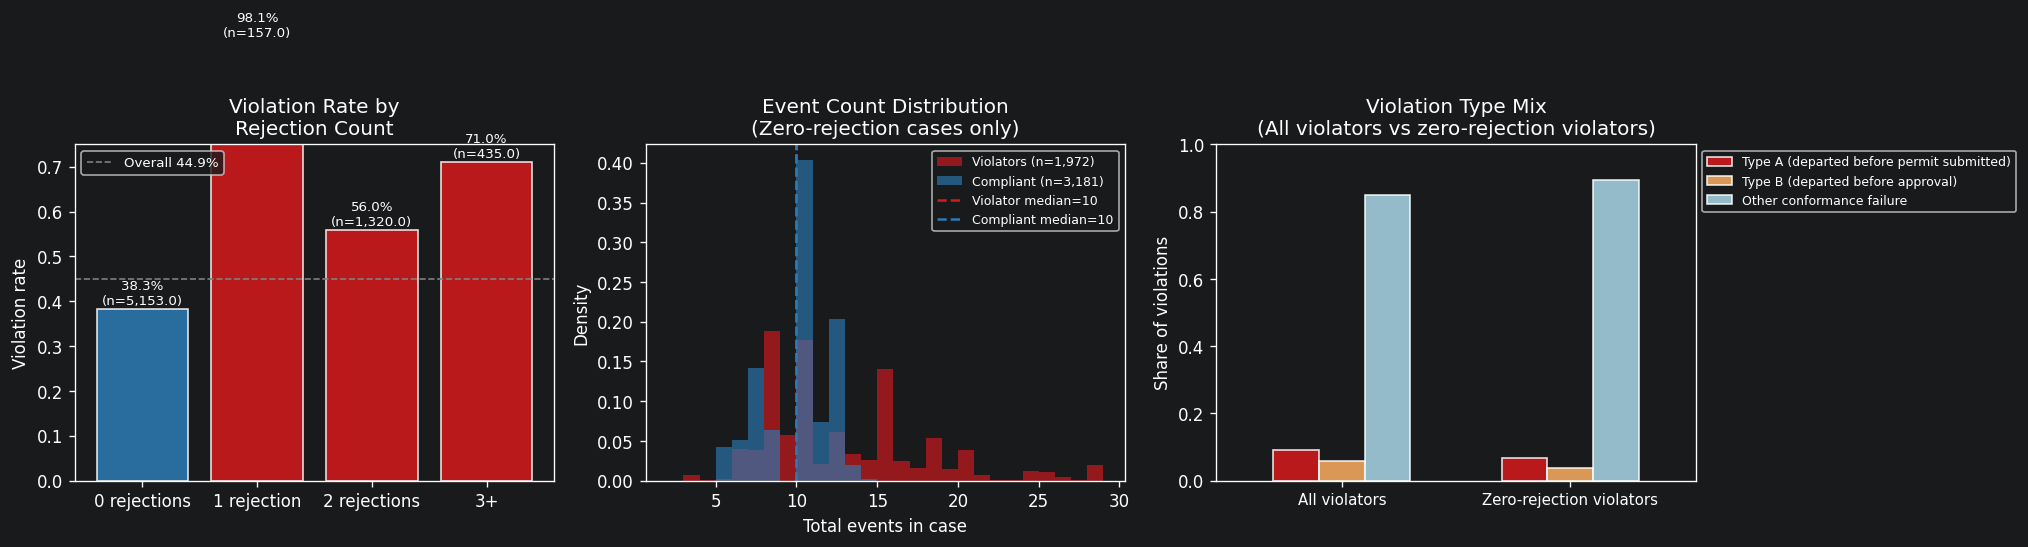

Saved violation_rejection_paradox.png


In [9]:
# ── 1. Violation rate by rejection bucket ─────────────────────────────────
fd = feat_df.copy()
fd['rej_bucket'] = pd.cut(fd['n_rejections'], bins=[-1, 0, 1, 2, 100],
                           labels=['0 rejections', '1 rejection', '2 rejections', '3+'])

bucket_stats = (fd.groupby('rej_bucket', observed=True)
                .agg(n=('has_violation', 'count'),
                     violations=('has_violation', 'sum'),
                     vio_rate=('has_violation', 'mean'),
                     type_a_rate=('type_a', 'mean'),
                     type_b_rate=('type_b', 'mean'),
                     median_events=('n_events', 'median'),
                     median_duration=('duration_days', 'median')))
bucket_stats['pct_cases'] = bucket_stats['n'] / len(fd)

print('Violation rate by rejection count:')
print(bucket_stats[['n', 'pct_cases', 'violations', 'vio_rate',
                     'type_a_rate', 'type_b_rate',
                     'median_events', 'median_duration']].to_string())
bucket_stats.to_csv(T / 'violation_rejection_paradox.csv')

# ── 2. Event count distribution — zero-rejection cases only ───────────────
zero_rej = fd[fd['n_rejections'] == 0].copy()
z_vio    = zero_rej[zero_rej['has_violation'] == 1]['n_events']
z_ok     = zero_rej[zero_rej['has_violation'] == 0]['n_events']

print(f'\nZero-rejection violators  — median events: {z_vio.median():.0f}  '
      f'mean: {z_vio.mean():.1f}  n={len(z_vio):,}')
print(f'Zero-rejection compliant  — median events: {z_ok.median():.0f}  '
      f'mean: {z_ok.mean():.1f}  n={len(z_ok):,}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: violation rate by bucket
colors = ['#d7191c' if r > fd['has_violation'].mean() else '#2c7bb6'
          for r in bucket_stats['vio_rate']]
axes[0].bar(bucket_stats.index, bucket_stats['vio_rate'],
            color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(fd['has_violation'].mean(), color='grey', linestyle='--',
                linewidth=1, label=f'Overall {fd["has_violation"].mean():.1%}')
for i, (idx, row) in enumerate(bucket_stats.iterrows()):
    axes[0].text(i, row['vio_rate'] + 0.01, f"{row['vio_rate']:.1%}\n(n={row['n']:,})",
                 ha='center', fontsize=8)
axes[0].set_ylabel('Violation rate')
axes[0].set_title('Violation Rate by\nRejection Count')
axes[0].set_ylim(0, 0.75)
axes[0].legend(fontsize=8)

# Panel 2: event count distribution for zero-rejection cases
bins = range(2, 30)
axes[1].hist(z_vio.clip(upper=29), bins=bins, alpha=0.65, color='#d7191c',
             label=f'Violators (n={len(z_vio):,})', density=True)
axes[1].hist(z_ok.clip(upper=29), bins=bins, alpha=0.65, color='#2c7bb6',
             label=f'Compliant (n={len(z_ok):,})', density=True)
axes[1].axvline(z_vio.median(), color='#d7191c', linestyle='--', linewidth=1.5,
                label=f'Violator median={z_vio.median():.0f}')
axes[1].axvline(z_ok.median(), color='#2c7bb6', linestyle='--', linewidth=1.5,
                label=f'Compliant median={z_ok.median():.0f}')
axes[1].set_xlabel('Total events in case')
axes[1].set_ylabel('Density')
axes[1].set_title('Event Count Distribution\n(Zero-rejection cases only)')
axes[1].legend(fontsize=7.5)

# Panel 3: violation type breakdown for zero-rejection violators vs all violators
all_vio = fd[fd['has_violation'] == 1]
type_comp = pd.DataFrame({
    'All violators':          [all_vio['type_a'].mean(), all_vio['type_b'].mean(),
                               1 - all_vio['type_a'].mean() - all_vio['type_b'].mean()],
    'Zero-rejection violators': [zero_rej[zero_rej['has_violation']==1]['type_a'].mean(),
                                 zero_rej[zero_rej['has_violation']==1]['type_b'].mean(),
                                 1 - zero_rej[zero_rej['has_violation']==1]['type_a'].mean()
                                   - zero_rej[zero_rej['has_violation']==1]['type_b'].mean()],
}, index=['Type A (departed before permit submitted)',
          'Type B (departed before approval)',
          'Other conformance failure'])

type_comp.T.plot(kind='bar', ax=axes[2], color=['#d7191c','#fdae61','#abd9e9'],
                 alpha=0.85, edgecolor='white', width=0.6)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0, fontsize=9)
axes[2].set_ylabel('Share of violations')
axes[2].set_title('Violation Type Mix\n(All violators vs zero-rejection violators)')
axes[2].legend(fontsize=7.5, bbox_to_anchor=(1, 1))
axes[2].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(OUT / 'violation_rejection_paradox.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved violation_rejection_paradox.png')

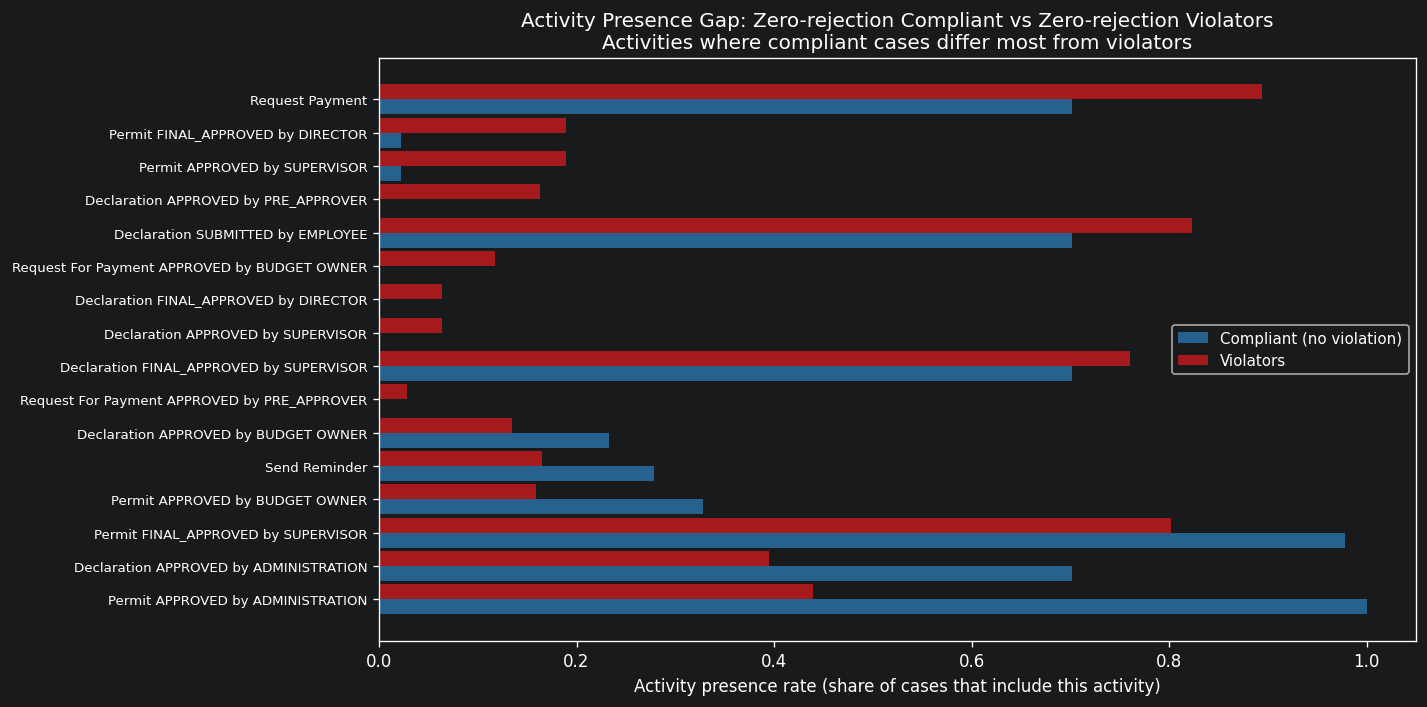


Top activity gaps (compliant rate − violator rate):
                                         rate_ok  rate_vio       gap
Permit APPROVED by ADMINISTRATION       1.000000  0.439655  0.560345
Declaration APPROVED by ADMINISTRATION  0.701981  0.395030  0.306950
Permit FINAL_APPROVED by SUPERVISOR     0.977994  0.801724  0.176270
Permit APPROVED by BUDGET OWNER         0.328513  0.158722  0.169791
Send Reminder                           0.278843  0.165314  0.113529
Declaration APPROVED by BUDGET OWNER    0.232946  0.134381  0.098564
Permit SUBMITTED by EMPLOYEE            1.000000  0.992394  0.007606
Start trip                              1.000000  1.000000  0.000000
End trip                                1.000000  1.000000  0.000000
Declaration SAVED by EMPLOYEE           0.009117  0.009128 -0.000011
Permit FOR_APPROVAL by ADMINISTRATION   0.000000  0.000507 -0.000507
Permit FOR_APPROVAL by SUPERVISOR       0.000000  0.000507 -0.000507

Saved violation_activity_gap.png


In [10]:
# ── 3. Activity gap analysis — what steps do zero-rejection violators skip? ─
# For each activity, compute presence rate in: zero-rejection compliant vs zero-rejection violators
zero_rej_ids   = set(zero_rej['case_id'])
zr_vio_ids     = set(zero_rej[zero_rej['has_violation'] == 1]['case_id'])
zr_ok_ids      = set(zero_rej[zero_rej['has_violation'] == 0]['case_id'])

df_zr = df[df['case_id'].isin(zero_rej_ids)].copy()

act_rates = {}
for act in df_zr['activity'].unique():
    cases_with_act = set(df_zr[df_zr['activity'] == act]['case_id'])
    act_rates[act] = {
        'rate_vio': len(cases_with_act & zr_vio_ids) / max(len(zr_vio_ids), 1),
        'rate_ok':  len(cases_with_act & zr_ok_ids)  / max(len(zr_ok_ids), 1),
    }

act_df = pd.DataFrame(act_rates).T
act_df['gap'] = act_df['rate_ok'] - act_df['rate_vio']  # positive = more common in compliant cases
act_df = act_df.sort_values('gap', ascending=False)

# Top 12 activities with the largest presence gap
top_gaps = act_df[act_df['gap'].abs() > 0.02].head(16)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(top_gaps))
ax.barh(y_pos, top_gaps['rate_ok'],  alpha=0.75, color='#2c7bb6',
        label='Compliant (no violation)', height=0.45, align='center')
ax.barh([p + 0.45 for p in y_pos], top_gaps['rate_vio'], alpha=0.75, color='#d7191c',
        label='Violators', height=0.45, align='center')
ax.set_yticks([p + 0.225 for p in y_pos])
ax.set_yticklabels([str(a)[:45] for a in top_gaps.index], fontsize=8)
ax.set_xlabel('Activity presence rate (share of cases that include this activity)')
ax.set_title('Activity Presence Gap: Zero-rejection Compliant vs Zero-rejection Violators\n'
             'Activities where compliant cases differ most from violators')
ax.legend(fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(0, 1.05)
plt.tight_layout()
fig.savefig(OUT / 'violation_activity_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop activity gaps (compliant rate − violator rate):')
print(act_df[['rate_ok', 'rate_vio', 'gap']].head(12).to_string())
act_df.to_csv(T / 'violation_activity_gap.csv')
print('\nSaved violation_activity_gap.png')

### Findings

**1. The 1-rejection group is the real anomaly.**
154 of 157 cases (98.1%) with exactly one rejection are violators. This is the sharpest signal in the dataset — not captured in the SHAP beeswarm, which averages across all rejection counts.

**2. The bypass hypothesis is wrong for most zero-rejection violators.**
Zero-rejection violators are not skipping the system. They submitted permits (`Permit SUBMITTED by EMPLOYEE`: 99.2% presence) and submitted declarations at a *higher* rate than compliant cases (82% vs 70%). What they skipped is the **Administration Approval gate**: `Permit APPROVED by ADMINISTRATION` is present in 100% of compliant cases but only 44% of violators.

**3. The SHAP direction is an interaction effect, not a marginal effect.**
The raw marginal rates (38% → 98% → 56% → 71% across rejection buckets) do not show a monotone protective relationship. The SHAP "high rejections → left" signal is captured in the decision tree: in cases with n_events > 13.5 and n_approvals ≤ 6.5, having > 1.5 rejections predicts *no violation*. After conditioning on trace length and approval count, multiple rejections signal that the case went through a genuine correction cycle.

**4. The mechanism underlying zero-rejection violations:**
Employees submit the permit but depart before Administration processes it. These cases are conformance failures at the administration approval step — not departure-before-submission (Type A rate is only 10% in the zero-rejection group). The process is being used *in the right order* but with insufficient lead time for administration review.

## 6. Lead time analysis — does submitting earlier prevent violations?

The activity gap showed `Permit APPROVED by ADMINISTRATION` is present in 100% of compliant cases but only 44% of violators. Two competing explanations:

- **Lead time hypothesis**: employees didn't submit early enough, so administration couldn't process in time before the trip
- **Routing/awareness hypothesis**: the permit was submitted but administration was never notified or never actioned it

If H1 is correct: violators should have short submit→trip gaps and administration should show slow processing times.  
If H2 is correct: violators can have long lead times (admin had plenty of time) and processing time, when it happens, should be fast.

Submit → trip gap (zero-rejection):
  Violators  median=35.4d  mean=45.4d  post-trip submissions: 6.1%
  Compliant  median=15.6d   mean=27.0d  post-trip submissions: 11.9%

Admin processing time (compliant cases, submit → approved):
  median=0.0d  p75=0.0d  p90=0.0d


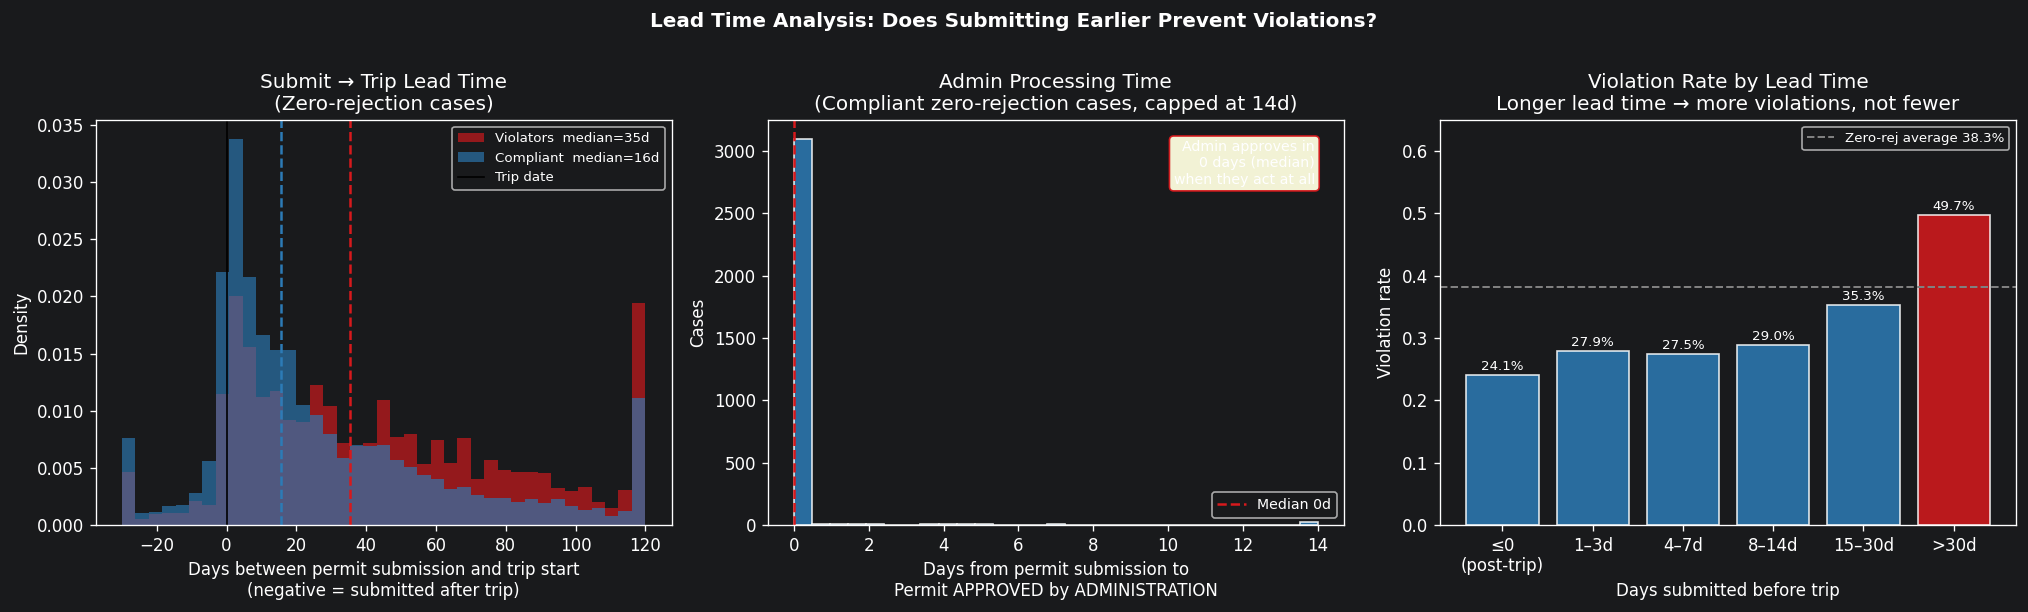

Saved violation_lead_time.png


In [11]:
TARGET_ACTS = {
    'Permit SUBMITTED by EMPLOYEE',
    'Permit APPROVED by ADMINISTRATION',
    'Start trip',
}
case_times = {}
for cid, grp in df.groupby('case_id'):
    times = {}
    for act in TARGET_ACTS:
        rows_act = grp[grp['activity'] == act]['timestamp']
        if len(rows_act):
            times[act] = rows_act.iloc[0]
    case_times[cid] = times

timing_rows = []
for cid, times in case_times.items():
    fitness_row = conf[conf.iloc[:,0] == cid]
    fitness     = fitness_row['fitness'].values[0] if len(fitness_row) else 1.0
    n_rej       = df[df['case_id']==cid]['activity'].str.contains('REJECTED').sum()
    sub_t  = times.get('Permit SUBMITTED by EMPLOYEE')
    trip_t = times.get('Start trip')
    adm_t  = times.get('Permit APPROVED by ADMINISTRATION')
    timing_rows.append({
        'case_id':           cid,
        'n_rejections':      n_rej,
        'has_violation':     int(fitness < 1.0),
        'submit_to_trip_d':  (trip_t - sub_t).total_seconds()/86400 if sub_t and trip_t else np.nan,
        'submit_to_adm_d':   (adm_t  - sub_t).total_seconds()/86400 if sub_t and adm_t  else np.nan,
        'has_adm_approval':  int(adm_t is not None),
    })
td = pd.DataFrame(timing_rows)

zr     = td[td['n_rejections'] == 0].copy()
zr_vio = zr[zr['has_violation'] == 1]
zr_ok  = zr[zr['has_violation'] == 0]

s2t_vio = zr_vio['submit_to_trip_d'].dropna()
s2t_ok  = zr_ok['submit_to_trip_d'].dropna()
s2a_ok  = zr_ok['submit_to_adm_d'].dropna()

print(f'Submit → trip gap (zero-rejection):')
print(f'  Violators  median={s2t_vio.median():.1f}d  mean={s2t_vio.mean():.1f}d  '
      f'post-trip submissions: {(s2t_vio<0).mean():.1%}')
print(f'  Compliant  median={s2t_ok.median():.1f}d   mean={s2t_ok.mean():.1f}d  '
      f'post-trip submissions: {(s2t_ok<0).mean():.1%}')
print(f'\nAdmin processing time (compliant cases, submit → approved):')
print(f'  median={s2a_ok.median():.1f}d  p75={s2a_ok.quantile(.75):.1f}d  '
      f'p90={s2a_ok.quantile(.9):.1f}d')

# Violation rate by lead time bucket
zr2 = zr.dropna(subset=['submit_to_trip_d']).copy()
zr2['lead_bin'] = pd.cut(zr2['submit_to_trip_d'],
                          bins=[-999, 0, 3, 7, 14, 30, 999],
                          labels=['≤0\n(post-trip)','1–3d','4–7d','8–14d','15–30d','>30d'])
lt_stats = (zr2.groupby('lead_bin', observed=True)
            .agg(n=('has_violation','count'), vio_rate=('has_violation','mean')))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Lead Time Analysis: Does Submitting Earlier Prevent Violations?',
             fontsize=12, fontweight='bold', y=1.01)

# Panel 1 — submit→trip distribution
bins = np.linspace(-30, 120, 40)
axes[0].hist(s2t_vio.clip(-30, 120), bins=bins, alpha=0.65, color='#d7191c', density=True,
             label=f'Violators  median={s2t_vio.median():.0f}d')
axes[0].hist(s2t_ok.clip(-30, 120),  bins=bins, alpha=0.65, color='#2c7bb6', density=True,
             label=f'Compliant  median={s2t_ok.median():.0f}d')
axes[0].axvline(s2t_vio.median(), color='#d7191c', linestyle='--', linewidth=1.5)
axes[0].axvline(s2t_ok.median(),  color='#2c7bb6', linestyle='--', linewidth=1.5)
axes[0].axvline(0, color='black', linewidth=1, label='Trip date')
axes[0].set_xlabel('Days between permit submission and trip start\n(negative = submitted after trip)')
axes[0].set_ylabel('Density')
axes[0].set_title('Submit → Trip Lead Time\n(Zero-rejection cases)')
axes[0].legend(fontsize=8)

# Panel 2 — admin processing time (compliant only)
axes[1].hist(s2a_ok.clip(0, 14), bins=np.linspace(0, 14, 30),
             color='#2c7bb6', alpha=0.85, edgecolor='white')
axes[1].axvline(s2a_ok.median(), color='#d7191c', linestyle='--', linewidth=1.5,
                label=f'Median {s2a_ok.median():.0f}d')
axes[1].set_xlabel('Days from permit submission to\nPermit APPROVED by ADMINISTRATION')
axes[1].set_ylabel('Cases')
axes[1].set_title('Admin Processing Time\n(Compliant zero-rejection cases, capped at 14d)')
axes[1].legend(fontsize=8.5)
axes[1].text(0.95, 0.95,
             f'Admin approves in\n0 days (median)\nwhen they act at all',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=8.5,
             bbox=dict(boxstyle='round', fc='lightyellow', ec='#d7191c', alpha=0.95))

# Panel 3 — violation rate by lead time bucket
colors = ['#d7191c' if r > zr['has_violation'].mean() else '#2c7bb6'
          for r in lt_stats['vio_rate']]
axes[2].bar(lt_stats.index, lt_stats['vio_rate'], color=colors, alpha=0.85, edgecolor='white')
axes[2].axhline(zr['has_violation'].mean(), color='grey', linestyle='--', linewidth=1.2,
                label=f'Zero-rej average {zr["has_violation"].mean():.1%}')
for i, (idx, row) in enumerate(lt_stats.iterrows()):
    axes[2].text(i, row['vio_rate'] + 0.008, f"{row['vio_rate']:.1%}",
                 ha='center', fontsize=8)
axes[2].set_xlabel('Days submitted before trip')
axes[2].set_ylabel('Violation rate')
axes[2].set_title('Violation Rate by Lead Time\nLonger lead time → more violations, not fewer')
axes[2].set_ylim(0, 0.65)
axes[2].legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUT / 'violation_lead_time.png', dpi=150, bbox_inches='tight')
plt.show()
td.to_csv(T / 'violation_lead_time.csv', index=False)
print('Saved violation_lead_time.png')

### Findings — lead time hypothesis rejected

**The lead time hypothesis is wrong.**

- Violators submit permits **earlier** than compliant cases (median 35.4d vs 15.6d before trip)
- Administration processes permits in **0 days** (median) when they act — there is no backlog
- Violation rate **increases** with longer lead time, not decreases
- Only 6.1% of zero-rejection violators submitted post-trip

**The routing/awareness hypothesis is supported.**

Administration had time to act but did not. This is not a capacity problem — it is a **notification or routing gap**. Permits are entering the system but not reaching the administration queue, or administration is marking them as actioned through an out-of-system channel that leaves no event log trace.

**Recommended intervention:**

Add an SLA check: if `Permit SUBMITTED by EMPLOYEE` appears but `Permit APPROVED by ADMINISTRATION` has not appeared within 2 business days, send an automated alert to the administration queue. Since administration approves in 0 days when engaged, this would close the gap with minimal process change.

In [12]:
# Save summary table
summary = pd.DataFrame([{
    'n_cases':              len(feat_df),
    'n_violations':         int(n_vio),
    'violation_rate':       f'{n_vio/len(feat_df):.1%}',
    'n_type_a':             int(feat_df["type_a"].sum()),
    'n_type_b':             int(feat_df["type_b"].sum()),
    'dt_cv_auc':            f'{dt_auc:.3f}',
    'xgb_cv_auc':           f'{xgb_auc:.3f}',
    'top_risk_dept':        dept_risk.index[0],
    'top_risk_dept_rate':   f'{dept_risk["rate"].iloc[0]:.1%}',
}])
summary.to_csv(T / 'violation_rca_summary.csv', index=False)
print('Summary:')
print(summary.T.to_string(header=False))

Summary:
n_cases              7065
n_violations         3174
violation_rate      44.9%
n_type_a              746
n_type_b              583
dt_cv_auc           0.876
xgb_cv_auc          0.956
top_risk_dept            
top_risk_dept_rate  44.9%
